# Assignment 2: Training Neural Networks in Practice

### Overview

In this assignment you will start with a poorly configured neural network trained on MNIST and systematically improve it using the techniques from the lecture. Each part isolates one technique so you can clearly observe its effect. In the final part you combine everything.

Training might take a little bit depending on your machine. In some cases using Google Colab might be a better option.

The missing code are mostly single lines. It's probably quicker looking it up in the PyTorch API documentation.

### Rules
- Run all cells in order. Do not skip cells.
- Each part has a **Starter Cell** (what you begin with) and a **Your Task** cell where you make changes.
- Answer all reflection questions in your own words. These refer to your specific results and will differ between students.
- Submit this `.ipynb` file with all cells executed and outputs visible.
- Allowed libraries: PyTorch, torchvision, NumPy, Matplotlib.

---

## Part 0: Setup and Baseline

We establish the dataset, a shared training loop, and a baseline network that performs poorly. Every subsequent part improves on this baseline.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
print('PyTorch version:', torch.__version__)

Using device: cpu
PyTorch version: 2.11.0+cu130


Train: 48,000  |  Val: 12,000  |  Test: 10,000


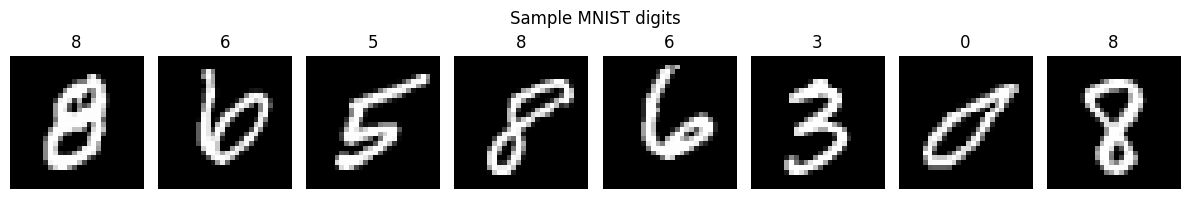

In [2]:
### DO NOT MODIFY THIS CELL ###

# Data loading


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 80/20 train/val split from the 60k training set
n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = torch.utils.data.random_split(full_train, [n_train, n_val],
                                                    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

print(f'Train: {len(train_set):,}  |  Val: {len(val_set):,}  |  Test: {len(test_set):,}')

# Quick sanity-check visualization
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()))
    ax.axis('off')
plt.suptitle('Sample MNIST digits')
plt.tight_layout()
plt.show()

In [3]:
### DO NOT MODIFY THIS CELL ###

# Shared training loop: All parts use this function.


def train_and_evaluate(model, train_loader, val_loader,
                        optimizer, criterion,
                        epochs=15, scheduler=None, early_stopping=None,
                        label='Model'):
    model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    stopped_at = None

    for epoch in range(epochs):
        # Training
        model.train()
        t_loss, t_correct, t_total = [], 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            t_loss.append(loss.item())
            t_correct += (out.argmax(1) == y).sum().item()
            t_total   += y.size(0)
        if scheduler:
            scheduler.step()

        # Validation
        model.eval()
        v_loss, v_correct, v_total = [], 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out  = model(X)
                v_loss.append(criterion(out, y).item())
                v_correct += (out.argmax(1) == y).sum().item()
                v_total   += y.size(0)

        history['train_loss'].append(np.mean(t_loss))
        history['val_loss'].append(np.mean(v_loss))
        history['train_acc'].append(100 * t_correct / t_total)
        history['val_acc'].append(100 * v_correct / v_total)

        if early_stopping:
            if early_stopping.step(history['val_loss'][-1], model):
                early_stopping.restore_best(model)
                stopped_at = epoch
                print(f'  Early stopping at epoch {epoch+1}')
                break

    return history, stopped_at


def plot_history(histories, title=''):
    """histories: dict of {label: history_dict}"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for label, h in histories.items():
        axes[0].plot(h['train_loss'], label=f'{label} train', linestyle='--')
        axes[0].plot(h['val_loss'],   label=f'{label} val')
        axes[1].plot(h['train_acc'],  label=f'{label} train', linestyle='--')
        axes[1].plot(h['val_acc'],    label=f'{label} val')
    for ax, ylabel in zip(axes, ['Loss', 'Accuracy (%)']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
    axes[0].set_title(f'{title} - Loss')
    axes[1].set_title(f'{title} - Accuracy')
    plt.tight_layout()
    plt.show()


def test_accuracy(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            correct += (model(X).argmax(1) == y).sum().item()
            total   += y.size(0)
    acc = 100 * correct / total
    print(f'Test Accuracy: {acc:.2f}%')
    return acc


print('Training loop ready.')

Training loop ready.


Baseline model architecture:
BaselineNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): Sigmoid()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): Sigmoid()
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): Sigmoid()
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 335,114

Training baseline...


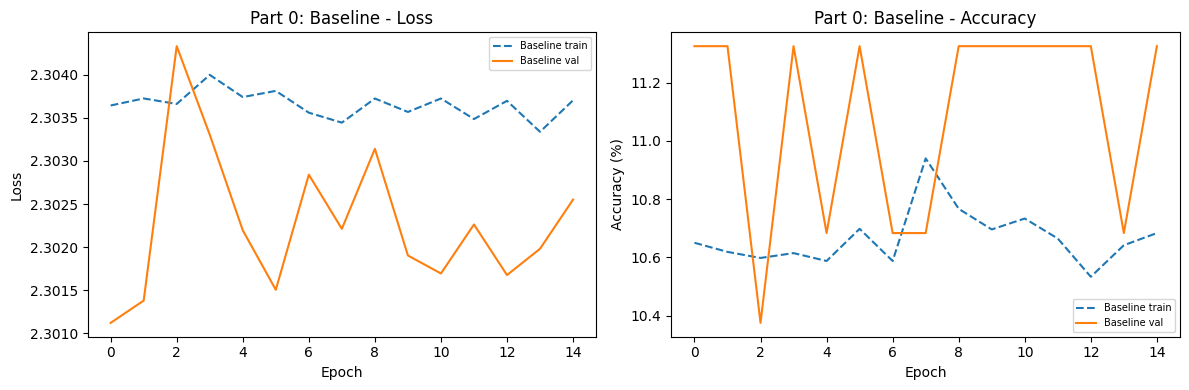


Baseline test accuracy:
Test Accuracy: 11.35%


In [4]:
### DO NOT MODIFY THIS CELL ###

# Baseline network.
# This network is intentionally misconfigured.
# It uses zero initialization and sigmoid activations: both poor choices for deep networks.
# You will improve it step by step in Parts 1–4.


class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.Sigmoid(),
            nn.Linear(256, 256), nn.Sigmoid(),
            nn.Linear(256, 256), nn.Sigmoid(),
            nn.Linear(256, 10)
        )
        # Zero initialization: intentionally bad
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.zeros_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


baseline_model = BaselineNet()
criterion      = nn.CrossEntropyLoss()
optimizer      = optim.SGD(baseline_model.parameters(), lr=0.01)

print('Baseline model architecture:')
print(baseline_model)
print(f'\nTotal parameters: {sum(p.numel() for p in baseline_model.parameters()):,}')

print('\nTraining baseline...')
baseline_history, _ = train_and_evaluate(
    baseline_model, train_loader, val_loader,
    optimizer, criterion, epochs=15, label='Baseline'
)
plot_history({'Baseline': baseline_history}, title='Part 0: Baseline')
print('\nBaseline test accuracy:')
baseline_acc = test_accuracy(baseline_model, test_loader)

### Part 0: Reflection

**Question 0a:** The baseline model barely learns anything despite having over 300,000 parameters. Based on the lecture, name the two specific configuration problems in `BaselineNet` and explain why each one hurts learning.

**Question 0b:** Look at the loss curves. Both training and validation loss behave similarly. Is this model underfitting or overfitting? How can you tell?

---
## Part 1: Activations and Initialization

Fix the two problems you identified in Part 0.

In [ ]:
### DO NOT MODIFY THIS CELL ###

# Part 1 Starter (same as baseline)
# This is what you start with.

class Part1Net_Starter(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.Sigmoid(),
            nn.Linear(256, 256), nn.Sigmoid(),
            nn.Linear(256, 256), nn.Sigmoid(),
            nn.Linear(256, 10)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.zeros_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [ ]:
# == Part 1: Your Task ==
# Replace sigmoid activations with ReLU.
# Replace zero initialization with He initialization.
# Keep everything else identical (same architecture, optimizer, lr, epochs).

class Part1Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),   # TODO: replace activation
            nn.Linear(256, 256), nn.ReLU(),   # TODO: replace activation
            nn.Linear(256, 256), nn.ReLU(),   # TODO: replace activation
            nn.Linear(256, 10)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


part1_model   = Part1Net()
part1_optim   = optim.SGD(part1_model.parameters(), lr=0.01)
part1_history, _ = train_and_evaluate(
    part1_model, train_loader, val_loader,
    part1_optim, criterion, epochs=15, label='Part1'
)
plot_history({'Baseline': baseline_history, 'Part 1: ReLU + He': part1_history},
             title='Part 1: Activation + Initialization')
print('Part 1 test accuracy:')
part1_acc = test_accuracy(part1_model, test_loader)

### Part 1: Reflection

**Question 1:** How much did test accuracy improve compared to the baseline? What does this tell you about the importance of these two choices?

---
## Part 2: Optimizer and Learning Rate

Start from the Part 1 network (ReLU + He init). Improve training speed and final accuracy by switching the optimizer and tuning the learning rate.

In [ ]:
### DO NOT MODIFY THIS CELL ###

# Part 2 Starter (Part 1 network, same optimizer)


def make_part2_net():
    """Returns a fresh Part1Net (ReLU + He) for fair comparison."""
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(784, 256), nn.ReLU(),
                nn.Linear(256, 256), nn.ReLU(),
                nn.Linear(256, 256), nn.ReLU(),
                nn.Linear(256, 10)
            )
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                    nn.init.zeros_(m.bias)
        def forward(self, x):
            return self.net(x)
    return Net()

# Starter: SGD, lr=0.01 (same as Part 1)
m_sgd = make_part2_net()
h_sgd, _ = train_and_evaluate(
    m_sgd, train_loader, val_loader,
    optim.SGD(m_sgd.parameters(), lr=0.01),
    criterion, epochs=15, label='SGD lr=0.01'
)
print('Starter (SGD lr=0.01) test accuracy:')
test_accuracy(m_sgd, test_loader)


In [ ]:
# == Part 2: Your Task ==
# Train two more versions of the same network:
#   A) SGD with momentum=0.9, lr=0.01
#   B) Adam, lr=1e-3
# Plot all four curves (starter + A + B) together.
# Then report test accuracy for A and B.

# TODO: Train model A: SGD with momentum
m_sgd_mom = make_part2_net()
h_sgd_mom, _ = train_and_evaluate(
    m_sgd_mom, train_loader, val_loader,
    ...,  # TODO: optimizer
    criterion, epochs=15
)

# TODO: Train model B: Adam
m_adam = make_part2_net()
h_adam, _ = train_and_evaluate(
    m_adam, train_loader, val_loader,
    ...,  # TODO: optimizer
    criterion, epochs=15
)

plot_history({
    'SGD lr=0.01':     h_sgd,
    'SGD+Mom lr=0.01': h_sgd_mom,
    'Adam lr=1e-3':    h_adam,
}, title='Part 2: Optimizer and Learning Rate')

print('SGD + Momentum test accuracy:')
test_accuracy(m_sgd_mom, test_loader)
print('Adam lr=1e-3 test accuracy:')
part2_acc = test_accuracy(m_adam, test_loader)


### Part 2: Reflection

**Question 2a:** Compare the SGD and SGD+Momentum curves. Describe the difference in shape. What does momentum physically do to the update steps that explains this difference?

**Question 2b:** Adam reaches good accuracy faster than SGD+Momentum. Does this mean Adam is always the better choice? Name one situation where SGD+Momentum is preferred.

---
## Part 3: Overfitting and Regularization

We first create a deliberate overfitting scenario by training on a small subset of the data. Then we apply dropout and L2 regularization to reduce the overfitting gap.

In [ ]:
### DO NOT MODIFY THIS CELL ###

# Part 3 Setup: small dataset to force overfitting


small_train = Subset(full_train, indices=list(range(1000)))
small_train_loader = DataLoader(small_train, batch_size=64, shuffle=True)
# Val loader stays the same (full val set): this makes the overfitting gap visible

def make_part3_net():
    """Fresh ReLU + He network for Part 3 comparisons."""
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Flatten(),
                nn.Linear(784, 256), nn.ReLU(),
                nn.Linear(256, 256), nn.ReLU(),
                nn.Linear(256, 256), nn.ReLU(),
                nn.Linear(256, 10)
            )
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                    nn.init.zeros_(m.bias)
        def forward(self, x):
            return self.net(x)
    return Net()

# Starter: no regularization, small dataset
m_overfit = make_part3_net()
h_overfit, _ = train_and_evaluate(
    m_overfit, small_train_loader, val_loader,
    optim.Adam(m_overfit.parameters(), lr=1e-3),
    criterion, epochs=30, label='No Reg'
)
plot_history({'No Regularization': h_overfit}, title='Part 3 Starter: Overfitting')
print('No regularization test accuracy (small dataset):')
test_accuracy(m_overfit, test_loader)


In [ ]:
# == Part 3: Your Task ==
# Train two regularized versions on the same small dataset:
#   A) Add Dropout(p=0.4) after each ReLU in the hidden layers
#   B) Add L2 regularization via weight_decay=1e-3 in the optimizer
# Keep Adam lr=1e-3 and 30 epochs for both.
# Plot all three val loss curves together.

# TODO: Model A: Dropout
class Part3Net_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), ...,  # TODO: add Dropout
            nn.Linear(256, 256), nn.ReLU(), ...,  # TODO: add Dropout
            nn.Linear(256, 256), nn.ReLU(), ...,  # TODO: add Dropout
            nn.Linear(256, 10)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

m_dropout = Part3Net_Dropout()
h_dropout, _ = train_and_evaluate(
    m_dropout, small_train_loader, val_loader,
    optim.Adam(m_dropout.parameters(), lr=1e-3),
    criterion, epochs=30
)

# TODO: Model B: L2 (weight decay)
m_l2 = make_part3_net()
h_l2, _ = train_and_evaluate(
    m_l2, small_train_loader, val_loader,
    ...,  # TODO: Adam with weight_decay=1e-3
    criterion, epochs=30
)

plot_history({
    'No Reg':  h_overfit,
    'Dropout': h_dropout,
    'L2':      h_l2,
}, title='Part 3: Regularization Comparison')

print('Dropout test accuracy:')
test_accuracy(m_dropout, test_loader)
print('L2 test accuracy:')
test_accuracy(m_l2, test_loader)


### Part 3: Reflection

**Question 3a:** Look at the starter (no regularization) loss curves. How large is the gap between training and validation accuracy at epoch 30? What does this tell you about what the model learned?

**Question 3b:** You trained on only 1,000 examples but tested on 10,000. Somebody says: "If you just trained on more data you wouldn't need regularization at all." Is this true? What is the relationship between dataset size and the need for regularization?

---
## Part 4: Batch Normalization

Return to the full training set. Add Batch Normalization to the network and observe the effect on training stability and convergence speed.

In [ ]:
### DO NOT MODIFY THIS CELL ###

# Part 4 Starter (ReLU + He + Adam, full dataset, no BN)


m_no_bn = make_part3_net()   # reuses the same architecture factory
h_no_bn, _ = train_and_evaluate(
    m_no_bn, train_loader, val_loader,
    optim.Adam(m_no_bn.parameters(), lr=1e-3),
    criterion, epochs=15, label='No BN'
)
print('No BatchNorm test accuracy:')
test_accuracy(m_no_bn, test_loader)


In [ ]:
# == Part 4: Your Task ==
# Add BatchNorm1d after each Linear layer and before the ReLU activation.
# Keep everything else the same.
# Plot both curves (no BN vs. with BN) and compare.


class Part4Net_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), ..., nn.ReLU(),  # TODO: insert BatchNorm1d(256)
            nn.Linear(256, 256), ..., nn.ReLU(),  # TODO: insert BatchNorm1d(256)
            nn.Linear(256, 256), ..., nn.ReLU(),  # TODO: insert BatchNorm1d(256)
            nn.Linear(256, 10)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

m_bn = Part4Net_BN()
h_bn, _ = train_and_evaluate(
    m_bn, train_loader, val_loader,
    optim.Adam(m_bn.parameters(), lr=1e-3),
    criterion, epochs=15, label='With BN'
)

plot_history({
    'No BatchNorm':   h_no_bn,
    'With BatchNorm': h_bn,
}, title='Part 4: Batch Normalization')

print('BatchNorm test accuracy:')
part4_acc = test_accuracy(m_bn, test_loader)


### Part 4: Reflection

**Question 4:** Describe the difference between the two loss curves. Does BatchNorm primarily help in the early epochs, the later epochs, or throughout? What does this tell you about what it is actually fixing?

---
## Part 5: Putting It All Together

Apply all techniques from Parts 1–4 in the correct order on the full dataset. Your goal is to build the best-performing model you can. You also implement early stopping and a learning rate scheduler here.

In [ ]:
# == Early Stopping ==
# Implement the EarlyStopping class.
# It is already integrated into train_and_evaluate: you just need to complete it.

import copy

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience    = patience
        self.best_loss   = float('inf')
        self.counter     = 0
        self.best_weights = None

    def step(self, val_loss, model):
        """
        Returns True if training should stop.
        Saves the best model weights when val_loss improves.
        """
        # TODO: implement
        pass

    def restore_best(self, model):
        """Restores model to the best saved weights."""
        # TODO: implement
        pass


In [ ]:
# == Part 5: Your Task ==
# Build your best model using everything from Parts 1–4.

# Requirements:
# - ReLU activations with He initialization          (Part 1)
# - Adam or AdamW optimizer                          (Part 2)
# - Dropout and/or L2 regularization                 (Part 3)
# - Batch Normalization                              (Part 4)
# - A learning rate scheduler (your choice)          (new)
# - Early stopping with patience=10                  (new)
# - Train for up to 50 epochs on the full dataset

# Then evaluate on the test set; only once, at the very end.

class MyBestNet(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: build your network
    def forward(self, x):
        return self.net(x)

best_model    = MyBestNet()
best_optimizer = ...  # TODO
best_scheduler = ...  # TODO
best_stopper   = EarlyStopping(patience=10)

best_history, stopped_at = train_and_evaluate(
    best_model, train_loader, val_loader,
    best_optimizer, criterion,
    epochs=50,
    scheduler=best_scheduler,
    early_stopping=best_stopper,
    label='Best Model'
)

plot_history({'Best Model': best_history}, title='Part 5: Best Model')
if stopped_at:
    print(f'Stopped early at epoch {stopped_at + 1}')

print('\nFinal test accuracy:')
final_acc = test_accuracy(best_model, test_loader)


In [ ]:
# == Progress summary ==
# Run this cell after completing all parts.

print('=' * 45)
print('       Accuracy Progression Summary')
print('=' * 45)
print(f'  Part 0: Baseline (zeros + sigmoid):  {baseline_acc:.2f}%')
print(f'  Part 1: ReLU + He init:              {part1_acc:.2f}%')
print(f'  Part 2: Adam optimizer:              {part2_acc:.2f}%')
print(f'  Part 4: + Batch Normalization:       {part4_acc:.2f}%')
print(f'  Part 5: Full best model:             {final_acc:.2f}%')
print('=' * 45)


### Part 5: Design Justification

Fill in the table with your choices and your reasoning.



| Choice                  | What you used | Why |
| ----------------------- | ------------- | --- |
| Activation function     |               |     |
| Weight initialization   |               |     |
| Optimizer               |               |     |
| Learning rate           |               |     |
| LR scheduler            |               |     |
| Dropout rate            |               |     |
| Weight decay            |               |     |
| BatchNorm position      |               |     |
| Early stopping patience |               |     |

### Part 5 — Reflection

**Question 5a:** Looking at the summary table, which single change between Part 0 and Part 5 produced the largest accuracy gain? Why does that particular change have such a large effect?

**Question 5b:** Your final test accuracy is the number you would report. Describe one way this number could still be an overestimate of how well your model would perform on truly new, real-world MNIST digits it has never seen in any form.